In [2]:
from langgraph.graph import StateGraph,START,END
from typing import TypedDict
from langgraph.checkpoint.memory import InMemorySaver
import time

In [4]:
# crating state
class crashState(TypedDict):
    input:str
    step1:str
    step2:str
    step3:str

In [6]:
def node1(state: crashState):
    print("step1 done")
    step1 = "Successfully executed node 1"
    return {'step1': step1}

In [7]:
def node2(state: crashState):
    print("Step2 hanging ... manually interrupt from notebook toolbar(STOP BUTTON)")
    time.sleep(30) # to stimulate hang
    step2 = "Successfully executed node 2"
    return {'step2': step2}

In [8]:
def node3(state: crashState):
    print("step3 done")
    step3 = "Successfully executed node 1"
    return {'step3': step3}

In [9]:
# Creating Graph
graph = StateGraph(crashState)

# Adding nodes to graph
graph.add_node("node1",node1)
graph.add_node("node2",node2)
graph.add_node("node3",node3)

# Adding edges to graph 
graph.add_edge(START,'node1')
graph.add_edge('node1','node2')
graph.add_edge('node2','node3')
graph.add_edge('node3',END)

# Creating checkpointers
checkpointer = InMemorySaver()

# Compile the graph 
workflow = graph.compile(checkpointer=checkpointer)

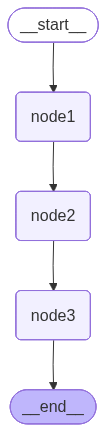

In [10]:
# Visualize the graph 
from IPython.display import Image
Image(workflow.get_graph().draw_mermaid_png())

In [12]:
config1 = {'configurable':{"thread_id":"1"}}
initial_state = {
    'input': "input"
}
workflow.invoke(initial_state,config=config1)

step1 done
Step2 hanging ... manually interrupt from notebook toolbar(STOP BUTTON)


KeyboardInterrupt: 

In [13]:

workflow.invoke(None,config=config1)

Step2 hanging ... manually interrupt from notebook toolbar(STOP BUTTON)
step3 done


{'input': 'input',
 'step1': 'Successfully executed node 1',
 'step2': 'Successfully executed node 2',
 'step3': 'Successfully executed node 1'}

In [15]:
workflow.get_state(config1)

StateSnapshot(values={'input': 'input', 'step1': 'Successfully executed node 1', 'step2': 'Successfully executed node 2', 'step3': 'Successfully executed node 1'}, next=(), config={'configurable': {'thread_id': '1', 'checkpoint_ns': '', 'checkpoint_id': '1f0fc19e-cf4e-6cf1-8006-08e03e8dff6f'}}, metadata={'source': 'loop', 'step': 6, 'parents': {}}, created_at='2026-01-28T07:21:12.834174+00:00', parent_config={'configurable': {'thread_id': '1', 'checkpoint_ns': '', 'checkpoint_id': '1f0fc19e-cf26-664b-8005-1faf3658873b'}}, tasks=(), interrupts=())

In [17]:
list(workflow.get_state_history(config1))

[StateSnapshot(values={'input': 'input', 'step1': 'Successfully executed node 1', 'step2': 'Successfully executed node 2', 'step3': 'Successfully executed node 1'}, next=(), config={'configurable': {'thread_id': '1', 'checkpoint_ns': '', 'checkpoint_id': '1f0fc19e-cf4e-6cf1-8006-08e03e8dff6f'}}, metadata={'source': 'loop', 'step': 6, 'parents': {}}, created_at='2026-01-28T07:21:12.834174+00:00', parent_config={'configurable': {'thread_id': '1', 'checkpoint_ns': '', 'checkpoint_id': '1f0fc19e-cf26-664b-8005-1faf3658873b'}}, tasks=(), interrupts=()),
 StateSnapshot(values={'input': 'input', 'step1': 'Successfully executed node 1', 'step2': 'Successfully executed node 2'}, next=('node3',), config={'configurable': {'thread_id': '1', 'checkpoint_ns': '', 'checkpoint_id': '1f0fc19e-cf26-664b-8005-1faf3658873b'}}, metadata={'source': 'loop', 'step': 5, 'parents': {}}, created_at='2026-01-28T07:21:12.802468+00:00', parent_config={'configurable': {'thread_id': '1', 'checkpoint_ns': '', 'checkpo